# Part 5. Time series forecasting - exercise

> Try your best in one of the Monash datasets!

Today you'll apply the knowledge acquired in part 5 to perform forecasting on one
of the datasets from the Monash time series forecasting archive (TSF). You don't
have to build the TSC algorithm from scratch if you don't want to, but rather make
use of high level tools. Use the ones used in previous exercises such as:
- [aeon](https://github.com/aeon-toolkit/aeon)
- [tsai](https://github.com/timeseriesAI/tsai)
- [tslearn](https://github.com/tslearn-team/tslearn#available-features)
- [sk-time](https://github.com/sktime/sktime)

Or new ones seen in this course:
- [statsmodels](https://www.statsmodels.org/stable/index.html). Implements traditional
statistical forecasting models.
- [pytorch-forecasting](https://pytorch-forecasting.readthedocs.io/en/stable/): Pytorch
library built on top of [pytorch lightning](https://lightning.ai/docs/pytorch/stable/)
that implements several neural forecasting models including NHiTS.

We are going to use the sunspot dataset. This dataset contains a single very long
daily time series of sunspot numbers from 1818-01-08 to 2020-05-31. Be aware that
there is missing data. The nonmissing data version of this dataset was filled with
the LOCV method of imputation.

## Preparing the data

Running the following code is **mandatory**, as it will load the datasets as meant for
the competition.

### Download

In [1]:
import requests
import zipfile
import os
url_train = 'https://zenodo.org/api/records/4654773/files-archive'
url_test = 'https://zenodo.org/api/records/4654722/files-archive'
# Download the zip file

DATA_FOLDER = 'data'
TEMP_FOLDER = 'raw_data'

response = requests.get(url_train)

def get(url):
    response = requests.get(url)
    zip_file_path = os.path.join(TEMP_FOLDER,'temp.zip')  # Specify the path to save the zip file
    with open(zip_file_path, 'wb') as file:
        file.write(response.content)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(TEMP_FOLDER)
    os.remove(zip_file_path)

def extract():
    extracted_zipfile = list(os.listdir(TEMP_FOLDER))[0]
    extracted_zipfile = os.path.join(TEMP_FOLDER, extracted_zipfile)
    with zipfile.ZipFile(extracted_zipfile, 'r') as zip_ref:
        zip_ref.extractall(DATA_FOLDER)
    os.remove(extracted_zipfile)

if not os.path.exists(TEMP_FOLDER):
    os.mkdir(TEMP_FOLDER)
if not os.path.exists('data'):
    os.mkdir(DATA_FOLDER)

get(url_train)
extract()
get(url_test)
extract()

os.rmdir(TEMP_FOLDER)

### Load to memory

In [2]:
# We use the aeon package to load the data. use ``!pip3 install aeon''
from aeon.datasets import load_from_tsf_file

#DATA_FOLDER = 'data' # Specify if the dataset is alread downloaded
TRAIN_DATA_FOLDER = os.path.join(DATA_FOLDER, 'sunspot_dataset_with_missing_values.tsf')
TEST_DATA_FOLDER = os.path.join(DATA_FOLDER, 'sunspot_dataset_without_missing_values.tsf')

missing_data, missing_metadata = load_from_tsf_file(TRAIN_DATA_FOLDER)
nonmissing_data, nonmissing_metadata = load_from_tsf_file(TEST_DATA_FOLDER)

print(missing_metadata)
print(nonmissing_metadata)

{'frequency': 'daily', 'forecast_horizon': None, 'contain_missing_values': True, 'contain_equal_length': True}
{'frequency': 'daily', 'forecast_horizon': None, 'contain_missing_values': False, 'contain_equal_length': True}


### Prepare train and test sets

In [3]:
import datetime
import numpy as np
import pandas as pd

def to_dataframe(dataset):
    numeric_data = np.array(dataset.series_value[0])
    interval_date = datetime.timedelta(days=1) * (len(numeric_data) - 1)
    start_date = dataset.start_timestamp[0]
    date_index = pd.date_range(start_date, interval_date + start_date , freq='D')
    return pd.DataFrame(numeric_data, index=date_index, columns=['sunspot'])

training_data = to_dataframe(missing_data).loc[:datetime.datetime(2019, 12, 31)].copy()
TESTING_DATA  = to_dataframe(nonmissing_data).loc[datetime.datetime(2020, 1, 1):].copy()

# Task Definition

You have available a training and testing dataset. Both ``training_data`` and ``TESTING_DATA`` are not preprocessed, while training data should be preprocessed, the testing data is to never be modified in any way. The training data contains sunspot information up to (not including) 2020-01-1, while the testing data contains information from 2020-01-1 to 2020-05-31. Your task is to adequately forecast the 2020-05-31. You have to generate a forecast for each day of the testing time series. The objective metric to minimize is *RMSE*.

> Good luck!


## Your implementation

In [4]:
training_data.tail()

,sunspot
2019-12-27,0.0
2019-12-28,0.0
2019-12-29,0.0
2019-12-30,0.0
2019-12-31,0.0


In [5]:
import pandas as pd
import numpy as np

# Fix dtype before anything else
training_data["sunspot"] = pd.to_numeric(training_data["sunspot"], errors="coerce")

In [6]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scattergl(  # Scattergl usa WebGL, mucho más rápido que Scatter
    x=training_data.index,
    y=training_data["sunspot"],
    mode="lines",
    line=dict(color="steelblue", width=0.8),
    name="Manchas solares",
))

fig.update_layout(
    title="Manchas solares — datos originales",
    xaxis=dict(
        title="Fecha",
        rangeselector=dict(buttons=[
            dict(count=1,  label="1a",  step="year",  stepmode="backward"),
            dict(count=5,  label="5a",  step="year",  stepmode="backward"),
            dict(count=20, label="20a", step="year",  stepmode="backward"),
            dict(step="all", label="Todo"),
        ]),
    ),
    yaxis_title="Manchas solares",
    height=1000,
)
fig.show()

In [7]:
'''
METHOD = "linear"  # opciones: "linear", "spline", "locf", "rolling"

if METHOD == "linear":
    imputed = training_data["sunspot"].interpolate(method="linear")
elif METHOD == "spline":
    imputed = training_data["sunspot"].interpolate(method="spline", order=3).clip(lower=0)
elif METHOD == "locf":
    imputed = training_data["sunspot"].ffill()
elif METHOD == "rolling":
    imputed = training_data["sunspot"].fillna(
        training_data["sunspot"].rolling(30, min_periods=1, center=True).mean()
    ).clip(lower=0)

training_data["sunspot"] = imputed
print(f"Método aplicado: {METHOD}")
print(f"NaNs restantes: {training_data['sunspot'].isna().sum()}")
'''

'\nMETHOD = "linear"  # opciones: "linear", "spline", "locf", "rolling"\n\nif METHOD == "linear":\n    imputed = training_data["sunspot"].interpolate(method="linear")\nelif METHOD == "spline":\n    imputed = training_data["sunspot"].interpolate(method="spline", order=3).clip(lower=0)\nelif METHOD == "locf":\n    imputed = training_data["sunspot"].ffill()\nelif METHOD == "rolling":\n    imputed = training_data["sunspot"].fillna(\n        training_data["sunspot"].rolling(30, min_periods=1, center=True).mean()\n    ).clip(lower=0)\n\ntraining_data["sunspot"] = imputed\nprint(f"Método aplicado: {METHOD}")\nprint(f"NaNs restantes: {training_data[\'sunspot\'].isna().sum()}")\n'

In [8]:
training_data["sunspot"] = pd.to_numeric(training_data["sunspot"], errors="coerce")

training_data_imputed = training_data.copy()
training_data_imputed["sunspot"] = training_data_imputed["sunspot"].interpolate(method="linear")

full_data = pd.concat([training_data_imputed, TESTING_DATA], axis=0)
full_data.index.name = "date"
full_data = full_data.reset_index()
full_data["time_idx"] = (full_data["date"] - full_data["date"].min()).dt.days
full_data["series_id"] = "sunspot"

In [9]:
'''
import datetime

# Serie completa train + test
full_data = pd.concat([training_data, TESTING_DATA])
full_data.index.name = "date"
full_data = full_data.reset_index()
full_data["time_idx"] = (full_data["date"] - full_data["date"].min()).dt.days
full_data["series_id"] = "sunspot"

print(f"Total días: {len(full_data)}")
print(f"Rango: {full_data['date'].min()} → {full_data['date'].max()}")
'''

'\nimport datetime\n\n# Serie completa train + test\nfull_data = pd.concat([training_data, TESTING_DATA])\nfull_data.index.name = "date"\nfull_data = full_data.reset_index()\nfull_data["time_idx"] = (full_data["date"] - full_data["date"].min()).dt.days\nfull_data["series_id"] = "sunspot"\n\nprint(f"Total días: {len(full_data)}")\nprint(f"Rango: {full_data[\'date\'].min()} → {full_data[\'date\'].max()}")\n'

In [10]:
# Diagnóstico
print(full_data["sunspot"].isna().sum())
print(full_data["sunspot"].isnull().sum())
print((full_data["sunspot"] == None).sum())

# Limpieza
full_data["sunspot"] = pd.to_numeric(full_data["sunspot"], errors="coerce")
full_data["sunspot"] = full_data["sunspot"].interpolate(method="linear").ffill().bfill()

# Verificación
print(f"NaNs restantes: {full_data['sunspot'].isna().sum()}")
print(f"Nones restantes: {full_data['sunspot'].isnull().sum()}")
print(full_data["sunspot"].dtype)

0
0
0
NaNs restantes: 0
Nones restantes: 0
float64


In [11]:
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, NHiTS
from pytorch_forecasting.metrics import MQF2DistributionLoss
import os

# ── Hyperparámetros ────────────────────────────────────────────────────────────
# Jan(31) + Feb(29, leap year) + Mar(31) + Apr(30) + May(31) = 152 days
MAX_PREDICTION_LENGTH = 152
MAX_ENCODER_LENGTH    = MAX_PREDICTION_LENGTH * 4   # 608 días de contexto

cutoff = full_data["time_idx"].max() - MAX_PREDICTION_LENGTH

print(f"Cutoff time_idx  : {cutoff}")
print(f"Max time_idx     : {full_data['time_idx'].max()}")
print(f"Min time_idx     : {full_data['time_idx'].min()}")
print(f"Encoder length   : {MAX_ENCODER_LENGTH}")
print(f"Prediction length: {MAX_PREDICTION_LENGTH}")

# ── Datasets ───────────────────────────────────────────────────────────────────
training_ds = TimeSeriesDataSet(
    full_data[full_data["time_idx"] <= cutoff],
    time_idx="time_idx",
    target="sunspot",
    group_ids=["series_id"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    time_varying_unknown_reals=["sunspot"],
    allow_missing_timesteps=True,
)

val_data = full_data[full_data["time_idx"] > (cutoff - MAX_ENCODER_LENGTH)].copy()

validation_ds = TimeSeriesDataSet.from_dataset(
    training_ds,
    val_data,
    predict=True,
    stop_randomization=True,
    allow_missing_timesteps=True
)

print(f"Training samples  : {len(training_ds)}")
print(f"Validation samples: {len(validation_ds)}")

# ── DataLoaders ────────────────────────────────────────────────────────────────
train_dl = training_ds.to_dataloader(train=True,  batch_size=1024, num_workers=14)
val_dl   = validation_ds.to_dataloader(train=False, batch_size=1024, num_workers=14)

# ── Modelo ─────────────────────────────────────────────────────────────────────
net = NHiTS.from_dataset(
    training_ds,
    learning_rate=1e-3,
    weight_decay=1e-2,
    loss=MQF2DistributionLoss(prediction_length=MAX_PREDICTION_LENGTH),
    backcast_loss_ratio=0.0,
    hidden_size=256,
    optimizer="AdamW",
)

# ── Trainer ────────────────────────────────────────────────────────────────────
trainer = pl.Trainer(
    accelerator="cuda",
    max_epochs=50,
    gradient_clip_val=0.1,
    default_root_dir=os.path.join(os.path.expanduser("~"), "lightning_logs"),
    callbacks=[pl.callbacks.EarlyStopping(monitor="val_loss", patience=10)],
)

trainer.fit(net, train_dl, val_dl)

Cutoff time_idx  : 73771
Max time_idx     : 73923
Min time_idx     : 0
Encoder length   : 608
Prediction length: 152
Training samples  : 73013
Validation samples: 1


/home/eder/miniconda3/envs/aeon_env/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/eder/miniconda3/envs/aeon_env/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/eder/miniconda3/envs/aeon_env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reas

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ MQF2DistributionLoss │ 26.7 K │ train │     0 │
│ 1 │ logging_metrics │ ModuleList           │      0 │ train │     0 │
│ 2 │ embeddings      │ MultiEmbedding       │      0 │ train │     0 │
│ 3 │ model           │ NHiTS                │  1.0 M │ train │     0 │
└───┴─────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 1.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.0 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/eder/miniconda3/envs/aeon_env/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

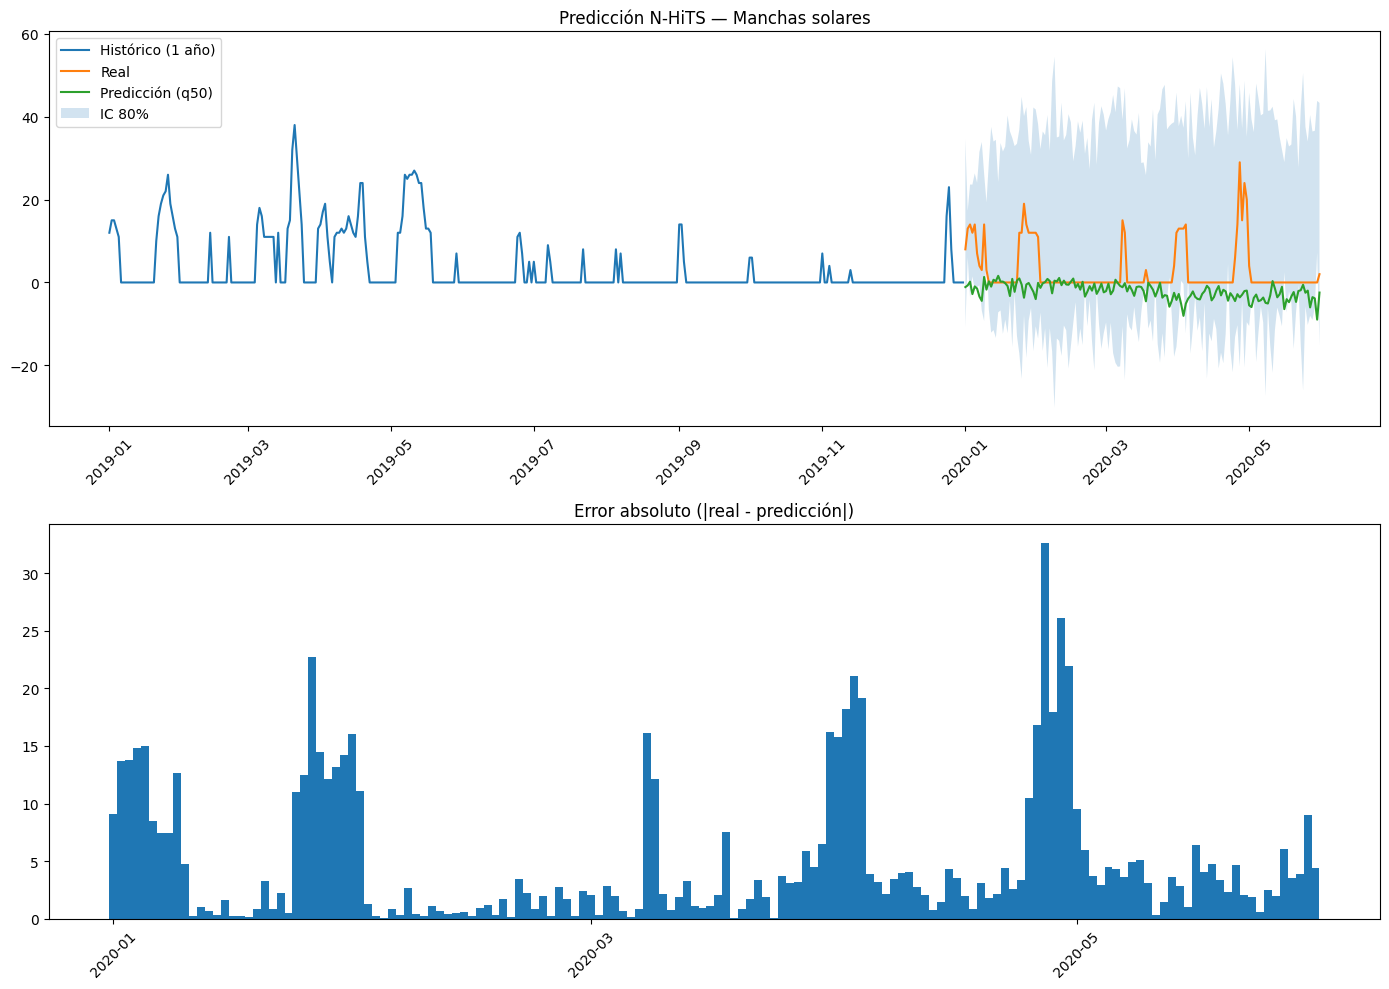

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE: 4.9995


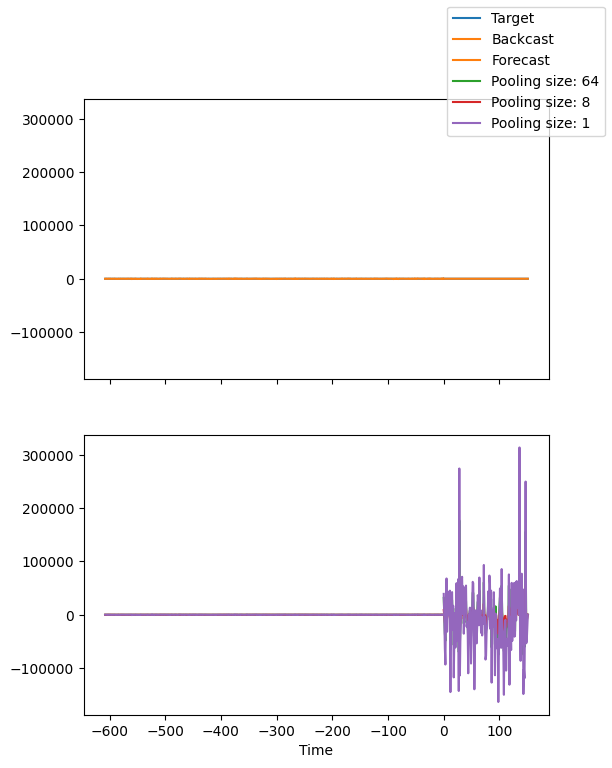

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Cargar modelo ---
best_model = NHiTS.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)

# --- Predicciones puntuales / reales ---
predictions = best_model.predict(
    val_dl,
    return_y=True,
    trainer_kwargs=dict(accelerator="cuda")
)

pred_values = predictions.output.cpu().numpy().squeeze()
true_values = predictions.y[0].cpu().numpy().squeeze()

# Fechas de predicción
pred_dates = TESTING_DATA.index[:len(true_values)]

# --- Cuantiles ---
# NHiTS con MQF2 devuelve 7 cuantiles:
# [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
raw_preds = best_model.predict(
    val_dl,
    mode="quantiles",
    trainer_kwargs=dict(accelerator="cuda")
).cpu().numpy().squeeze()

# Si hay una sola serie/window, raw_preds tendrá forma (prediction_length, 7)
# Tomamos los cuantiles 10, 50 y 90
q10 = raw_preds[:, 1]
q50 = raw_preds[:, 3]
q90 = raw_preds[:, 5]

# --- Plot predicciones ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Contexto + predicción
ax = axes[0]
context = training_data_imputed["sunspot"].iloc[-365:]
ax.plot(context.index, context.values, label="Histórico (1 año)")
ax.plot(pred_dates, true_values, label="Real", linewidth=1.5)
ax.plot(pred_dates, q50, label="Predicción (q50)", linewidth=1.5)
ax.fill_between(pred_dates, q10, q90, alpha=0.2, label="IC 80%")
ax.set_title("Predicción N-HiTS — Manchas solares")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Error absoluto
ax2 = axes[1]
error = np.abs(true_values - q50)
ax2.bar(pred_dates, error, width=1)
ax2.set_title("Error absoluto (|real - predicción|)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# --- MAE final ---
mae = np.mean(np.abs(true_values - q50))
print(f"MAE: {mae:.4f}")

# --- Interpretación por bloque N-HiTS ---
raw_predictions = best_model.predict(
    val_dl,
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="cuda")
)

best_model.plot_interpretation(
    raw_predictions.x,
    raw_predictions.output,
    idx=0
)
plt.show()